# Exploratory Data Analysis

## Roles to Explore:

In [1]:
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt

# Load the dataset
dataset = load_dataset("lukebarousse/data_jobs")
df=dataset["train"].to_pandas()

# Data Cleanup
df['job_posted_date']=pd.to_datetime(df['job_posted_date'])
df['job_skills']=df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

C:\Users\IDEAPADGAMING\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Filter for India Data Analyst roles

In [ ]:
df_DA_In=df[(df['job_title_short']=='Data Analyst') & (df['job_country']=='India')]


C:\Users\IDEAPADGAMING\AppData\Local\Temp\ipykernel_123192\2900005959.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_plot,x='count',y='job_location',palette='dark:b_r',legend=False)


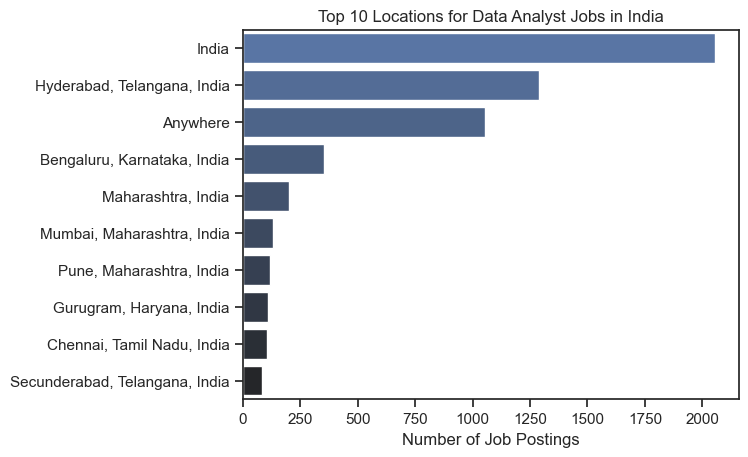

In [27]:
df_plot=df_DA_In['job_location'].value_counts().head(10).to_frame()

sns.set_theme(style='ticks')
sns.barplot(data=df_plot,x='count',y='job_location',palette='dark:b_r',legend=False)
plt.title('Top 10 Locations for Data Analyst Jobs in India')
plt.xlabel('Number of Job Postings')
plt.ylabel('')
plt.show()

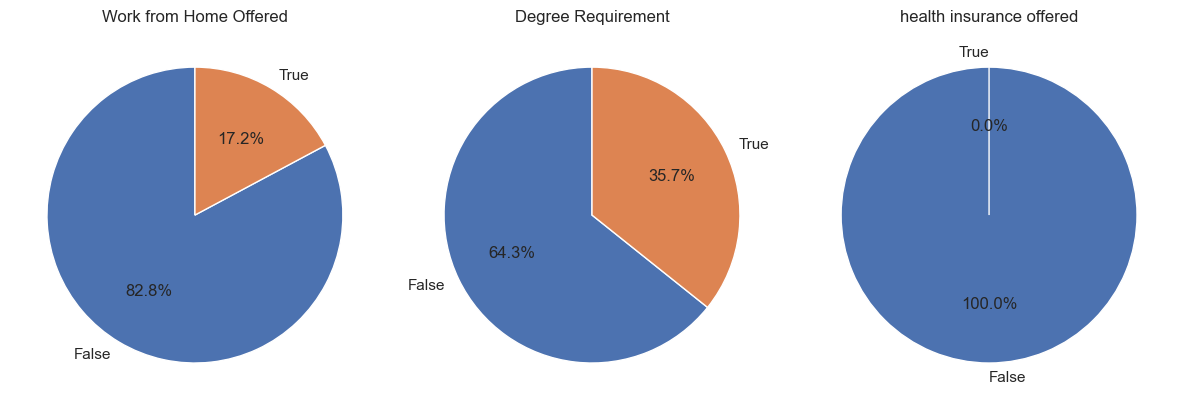

In [35]:
dict_column={
    'job_work_from_home':'Work from Home Offered',
    'job_no_degree_mention':'Degree Requirement',
    'job_health_insurance':'health insurance offered'
}

fig,ax=plt.subplots(1,3)
fig.set_size_inches(12,5)

for i,(column,title) in enumerate(dict_column.items()):
    counts = df_DA_In[column].value_counts().reindex([False, True], fill_value=0)
    ax[i].pie(counts,labels=['False','True'],autopct='%1.1f%%',startangle=90)
    ax[i].set_title(title)

fig.tight_layout()
plt.show()

C:\Users\IDEAPADGAMING\AppData\Local\Temp\ipykernel_123192\4117406603.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_plot,x='count',y='company_name',palette='dark:b_r',legend=False)


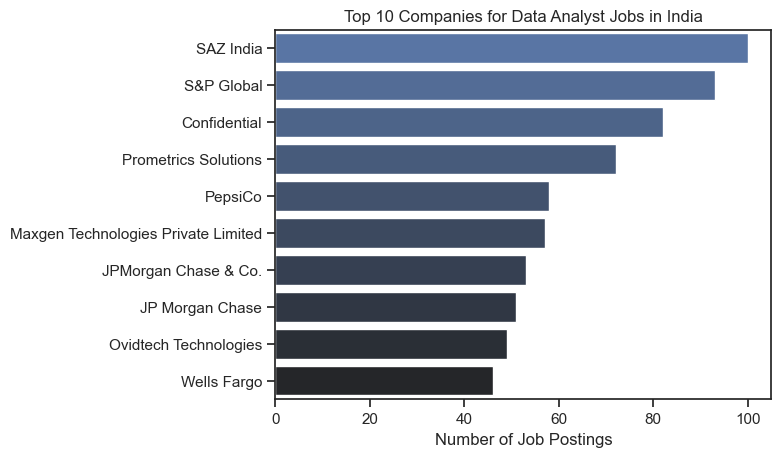

In [36]:
df_plot=df_DA_In['company_name'].value_counts().head(10).to_frame()

sns.set_theme(style='ticks')
sns.barplot(data=df_plot,x='count',y='company_name',palette='dark:b_r',legend=False)
plt.title('Top 10 Companies for Data Analyst Jobs in India')
plt.xlabel('Number of Job Postings')
plt.ylabel('')
plt.show()